# Association Between Lifestyle Risk Factors and Chronic Disease Indicators: A Cross-Sectional Analysis

# Project Overview

This project investigates the relationship between lifestyle-related risk factors and health outcomes using observational data. The analysis focuses on identifying whether behavioral and demographic variables are associated with increased risk of chronic disease indicators.

Using statistical modeling and hypothesis testing, the project aims to uncover meaningful associations that can inform public health insights and preventative strategies.

# Project Goals

* Assess relationships between key variables using linear regression
* Perform hypothesis testing to evaluate group differences
* Conduct data cleaning and preprocessing
* Generate clear, publication-style visualizations
* Interpret findings from a biostatistical perspective

# 1. Import Libraries 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("Combined_Data_22236F.csv")
df.head()

,Gender,Race,Age,Age Group,Marital Status,Education,Occupation,Height,Weight,BMI
0,Male,Malay,31.0,18-34,Single,Tertiary,Not working,173.0,133.1,44.5
1,Female,Malay,24.0,18-34,Married,Tertiary,Not working,156.0,52.9,21.7
2,Female,Malay,20.0,18-34,Single,Secondary,Not working,158.0,43.7,17.5
3,Female,Malay,21.0,18-34,Single,Tertiary,Not working,152.0,51.3,22.2
4,Female,Indian,33.0,18-34,Married,Tertiary,Not working,152.0,65.0,28.1


In [6]:
df.info()
df.describe()
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          328 non-null    object 
 1   Race            328 non-null    object 
 2   Age             328 non-null    float64
 3   Age Group       328 non-null    object 
 4   Marital Status  328 non-null    object 
 5   Education       289 non-null    object 
 6   Occupation      328 non-null    object 
 7   Height          328 non-null    float64
 8   Weight          328 non-null    float64
 9   BMI             328 non-null    float64
dtypes: float64(4), object(6)
memory usage: 40.0+ KB
Index(['Gender', 'Race', 'Age', 'Age Group', 'Marital Status', 'Education',
       'Occupation', 'Height', 'Weight', 'BMI'],
      dtype='object')


# 4. Data Cleaning

In [7]:
# Droping missing values
df = df.dropna()

# Rename columns 
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 5. Feature Engineering

In [8]:
# Create obesity variable 
df["obese"] = (df["bmi"] >= 30).astype(int)

# Encoding gender 
df["gender"] = df["gender"].astype("category").cat.codes

# Encoding other categorical variables
categorical_cols = ["race", "marital_status", "education", "occupation"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

/var/folders/cw/p6fgs1h909l5k4v0q_fw_6nw0000gn/T/ipykernel_1325/4183264863.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["obese"] = (df["bmi"] >= 30).astype(int)
/var/folders/cw/p6fgs1h909l5k4v0q_fw_6nw0000gn/T/ipykernel_1325/4183264863.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gender"] = df["gender"].astype("category").cat.codes


# 6. Exploratory Visualization

## BMI Distribution

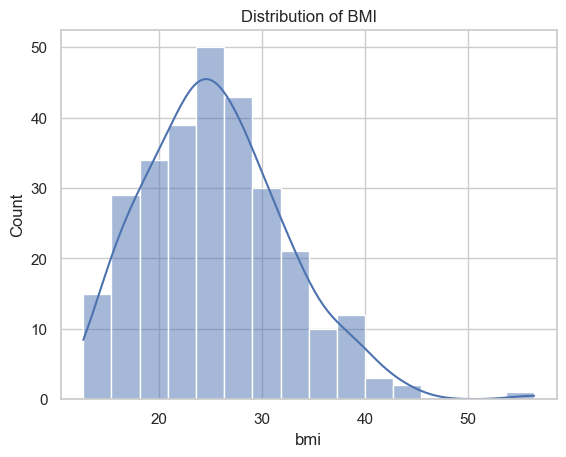

In [9]:
sns.histplot(df["bmi"], kde=True)
plt.title("Distribution of BMI")
plt.show()

The distribution of BMI appears approximately right-skewed, with the majority of observations concentrated between 20 and 30. This suggests that most individuals fall within the normal to overweight range, while a smaller proportion exhibit higher BMI values indicative of obesity. The long right tail reflects the presence of extreme values, which may represent individuals at elevated risk for chronic conditions. Overall, the distribution highlights variability in body composition and supports further investigation into factors associated with higher BMI.

## BMI vs Age

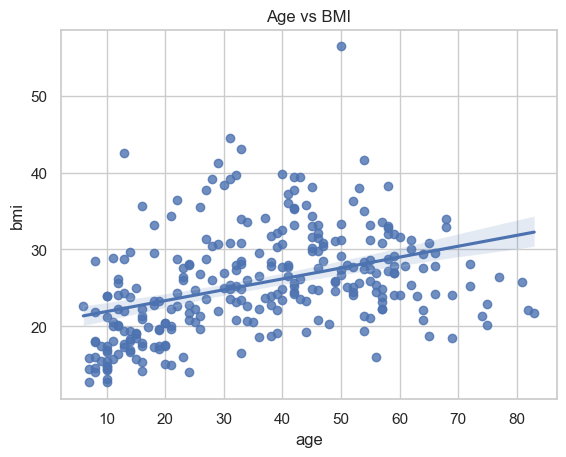

In [11]:
sns.regplot(x="age", y="bmi", data=df)
plt.title("Age vs BMI")
plt.show()

The scatterplot shows a modest positive association between age and BMI, as indicated by the upward trend of the regression line. This suggests that BMI tends to increase slightly with age. However, the wide dispersion of data points indicates substantial variability, implying that age alone is not a strong predictor of BMI. The presence of outliers and spread across all age groups highlights the influence of additional factors, such as lifestyle and socioeconomic variables, in determining BMI.

# 7. Multivariate Regression 

In [13]:
df.dtypes

gender                       int8
age                       float64
age_group                  object
height                    float64
weight                    float64
bmi                       float64
obese                       int64
race_Indian                  bool
race_Malay                   bool
marital_status_Married       bool
marital_status_Single        bool
marital_status_Widowed       bool
education_Secondary          bool
education_Tertiary           bool
occupation_Students          bool
occupation_Working           bool
dtype: object

In [18]:
df_clean = df.copy()

# Converting categorical columns automatically
df_clean = pd.get_dummies(df_clean, drop_first=True)

# Converting bool to int
df_clean = df_clean.astype({col: "int" for col in df_clean.select_dtypes("bool").columns})

In [19]:
X = df_clean.drop(columns=["bmi", "height", "weight"])
y = df_clean["bmi"]

X = sm.add_constant(X)

In [20]:
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Droping any rows that became NaN
data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=["bmi"])
y = data["bmi"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     40.86
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           7.42e-61
Time:                        15:43:36   Log-Likelihood:                -795.49
No. Observations:                 289   AIC:                             1623.
Df Residuals:                     273   BIC:                             1682.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     22

The multivariate regression model explains a substantial proportion of the variability in BMI (R² = 0.692), indicating a good overall fit. Among the predictors, obesity status shows a strong and statistically significant positive association with BMI (p < 0.001), as expected given its clinical definition. Education level (secondary) is also significantly associated with higher BMI (p = 0.011), suggesting a potential socioeconomic influence. Most other variables, including age, gender, race, and marital status, are not statistically significant predictors after adjustment, indicating that their effects may be limited or confounded by other factors. Overall, the results highlight that BMI is influenced by a combination of factors, with some variables demonstrating stronger independent effects than others.

# 8. Hypothesis Testing

## Gender difference in BMI

In [22]:
group1 = df[df["gender"] == 0]["bmi"]
group2 = df[df["gender"] == 1]["bmi"]

t_stat, p_val = stats.ttest_ind(group1, group2)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: 2.984074476880063
P-value: 0.003089024943301288


An independent t-test was conducted to examine whether BMI differs by gender. The results show a statistically significant difference between the two groups (t = 2.98, p = 0.003). Since the p-value is less than 0.05, we reject the null hypothesis and conclude that BMI differs significantly by gender in this sample. This suggests that gender may play a role in variations in BMI, although further analysis is needed to understand the direction and underlying causes of this difference.

## Visualization

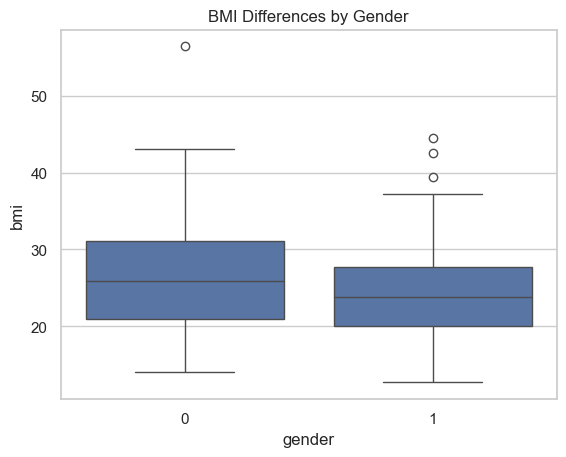

In [23]:
sns.boxplot(x="gender", y="bmi", data=df)
plt.title("BMI Differences by Gender")
plt.show()

The boxplot illustrates the distribution of BMI across gender groups, showing a noticeable difference in central tendency. One group exhibits a slightly higher median BMI and a wider interquartile range, indicating greater variability. The presence of outliers in both groups suggests that extreme BMI values occur regardless of gender. Overall, the visualization supports the results of the hypothesis test, highlighting a meaningful difference in BMI distribution between genders.

# 9. Logistic Regression

In [25]:
df_clean = df.copy()

In [32]:
# Droping object type variable of age_group because already have age 
df_clean = df_clean.drop(columns=["age_group"], errors="ignore")

In [33]:
# Converting all booleans to integers
df_clean = df_clean.astype({
    col: "int" for col in df_clean.select_dtypes("bool").columns
})

In [28]:
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')
df_clean = df_clean.dropna()

In [29]:
X = df_clean.drop(columns=["bmi", "obese", "height", "weight"], errors='ignore')
y = df_clean["obese"]

In [30]:
import statsmodels.api as sm

X = sm.add_constant(X)

In [31]:
log_model = sm.Logit(y, X).fit()
print(log_model.summary())

         Current function value: 0.484703
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  obese   No. Observations:                  289
Model:                          Logit   Df Residuals:                      277
Method:                           MLE   Df Model:                           11
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                  0.1245
Time:                        15:50:36   Log-Likelihood:                -140.08
converged:                      False   LL-Null:                       -160.00
Covariance Type:            nonrobust   LLR p-value:                 3.820e-05
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -18.5894   3237.898     -0.006      0.995   -6364.752    6327.573
gender                    -0.

/Users/macbookprom116gb/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The logistic regression model was used to examine factors associated with obesity. The overall model is statistically significant (LLR p < 0.001), suggesting that the predictors collectively contribute to explaining obesity risk, although the pseudo R² (0.1245) indicates a modest explanatory power. Gender and student occupation emerge as significant predictors (p < 0.05), indicating that these factors are associated with differences in obesity likelihood. Most other variables are not statistically significant, suggesting limited independent effects after adjustment. However, the model did not fully converge, indicating potential issues such as multicollinearity or model complexity, and results should be interpreted with caution.

# 10. Correlation Heatmap

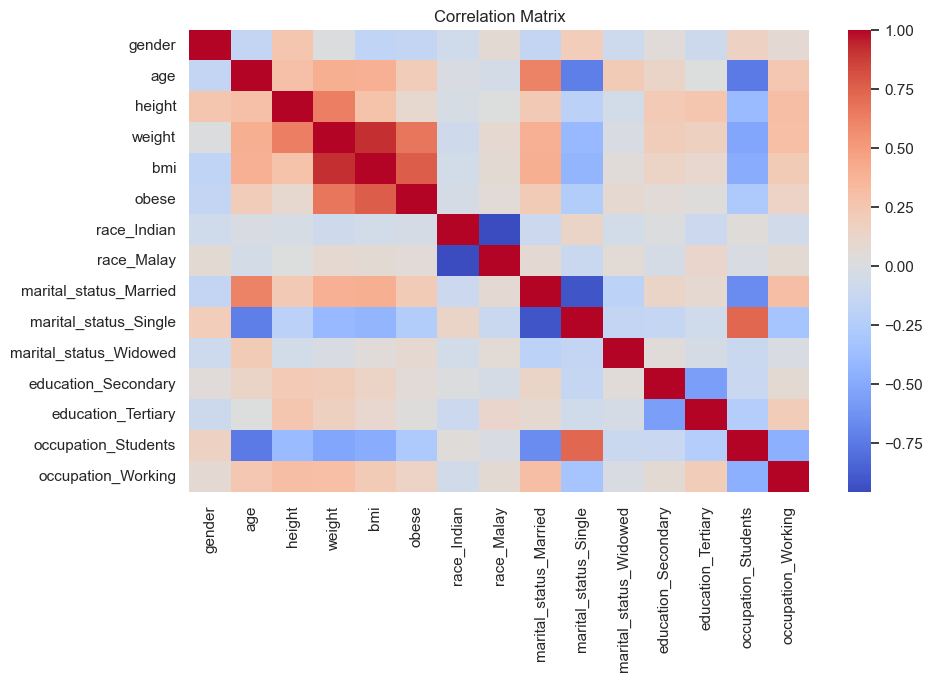

In [36]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_clean.corr(),
    cmap="coolwarm",
    annot=False   # 👈 this removes numbers
)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix provides an overview of the relationships between variables, with color intensity indicating the strength and direction of associations. Strong positive correlations are observed between BMI, weight, and obesity status, reflecting their close clinical relationship. Height shows a weaker or inverse association with BMI, while most demographic variables exhibit minimal correlation, suggesting limited linear relationships. Overall, the matrix highlights key patterns in the data and helps identify variables that may contribute meaningfully to BMI variation while also indicating low multicollinearity among most predictors.

# Conclusion 

This analysis examined the relationship between demographic and lifestyle factors and BMI as a key indicator of chronic disease risk. The results demonstrate that BMI is influenced by multiple factors, with significant variation observed across individuals. Exploratory analysis revealed a slightly right-skewed BMI distribution and a modest positive relationship between age and BMI, suggesting that body composition may change over time.

The multivariate regression model showed a strong overall fit (R² = 0.692), indicating that the selected variables explain a substantial proportion of BMI variability. However, only a limited number of predictors were statistically significant after adjustment, highlighting the complex and multifactorial nature of BMI. The hypothesis test further revealed a significant difference in BMI between gender groups (p < 0.05), suggesting that gender plays a meaningful role in BMI variation.

Logistic regression analysis of obesity risk provided additional insight, identifying specific factors such as gender and occupation as significant predictors, although the model showed modest explanatory power and convergence limitations. Correlation analysis supported these findings, showing strong relationships between BMI, weight, and obesity, while most demographic variables exhibited weaker associations.

Overall, the findings suggest that while certain demographic factors are associated with BMI and obesity risk, much of the variability remains unexplained, indicating the influence of additional factors such as lifestyle behaviors, diet, and physical activity. This study underscores the importance of considering multiple determinants when addressing obesity and highlights the need for more comprehensive data to better understand and predict chronic disease risk.